/var/folders/6k/ynvvp9ns3m55tkc0826zx_040000gn/T/ipykernel_6237/4088903596.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("turbo", n)


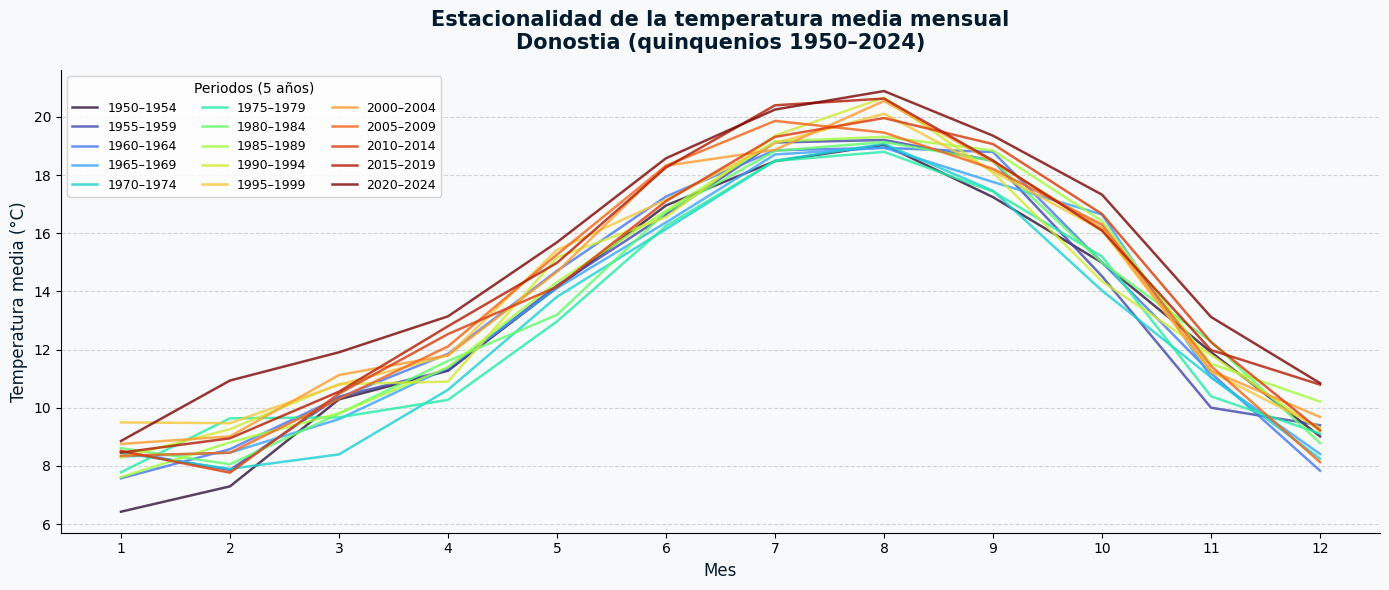

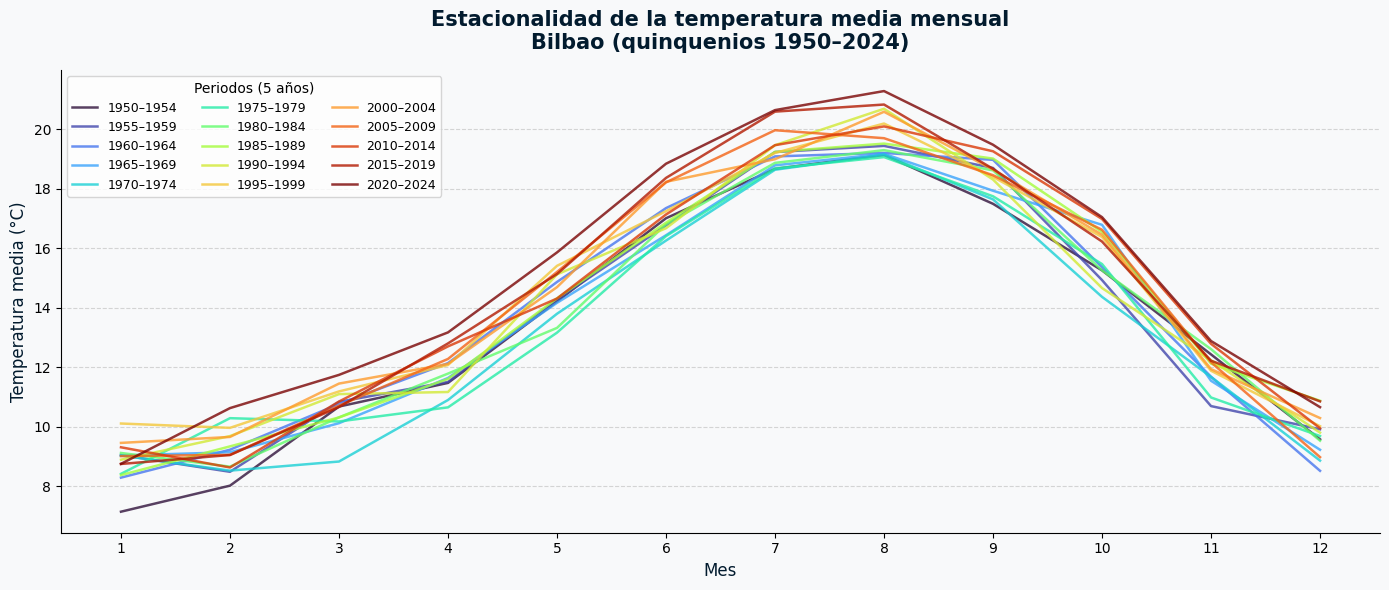

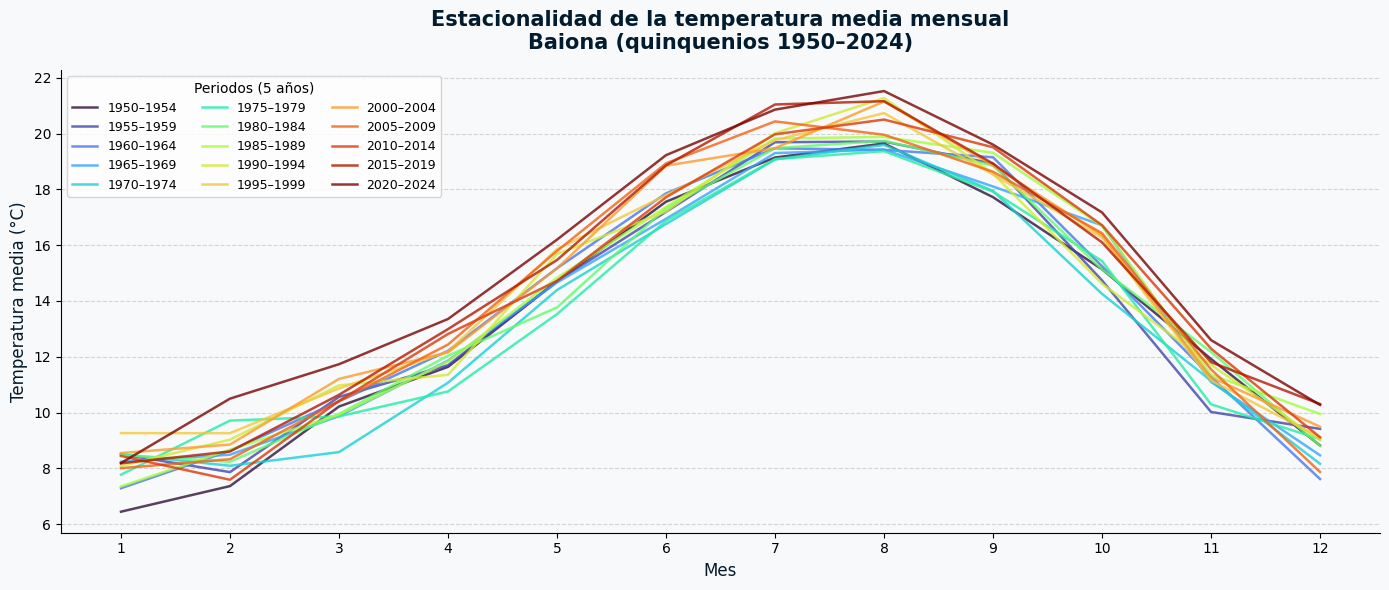

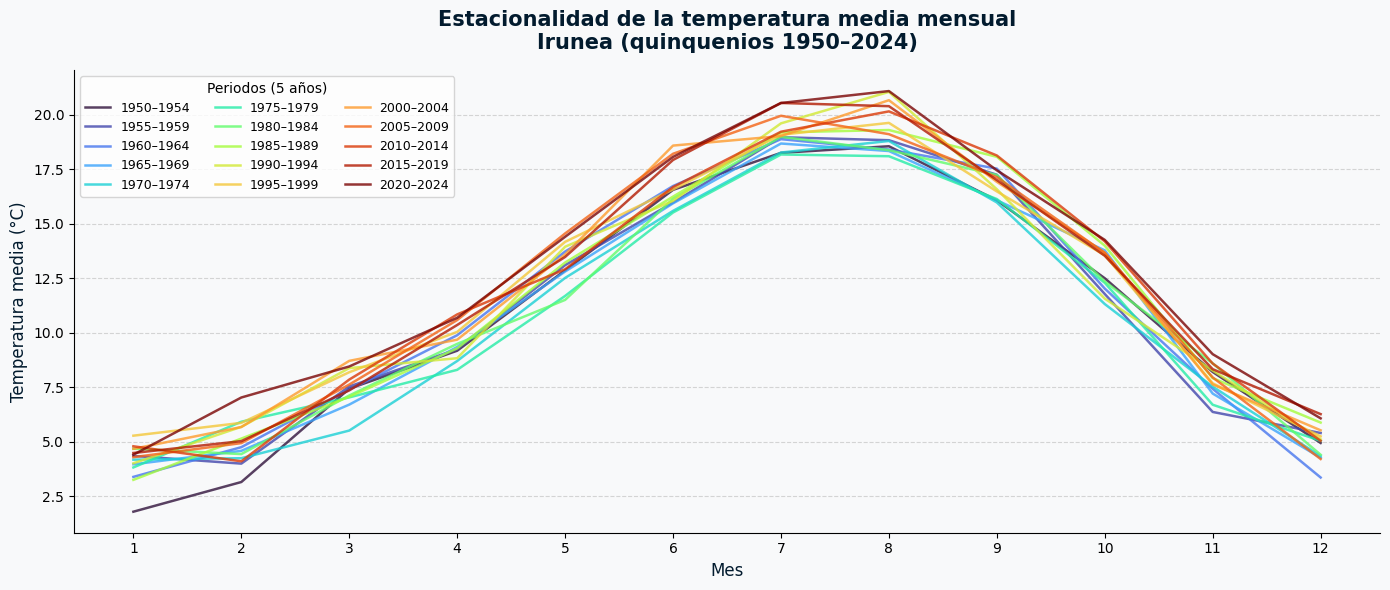

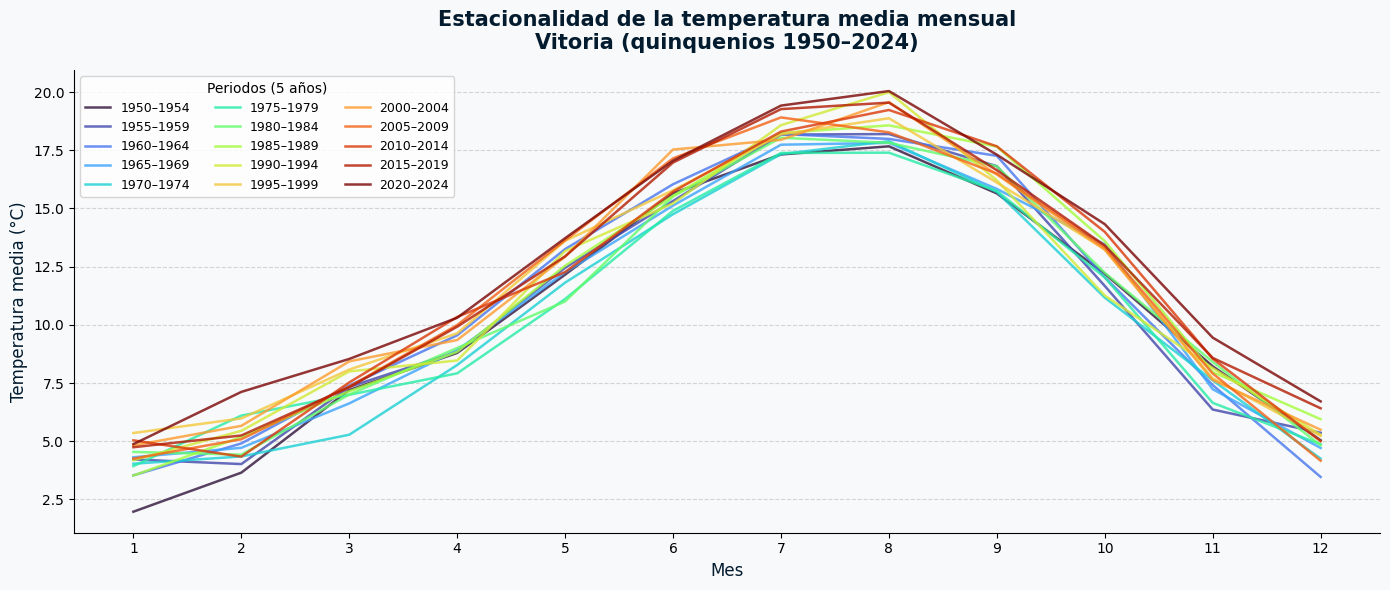

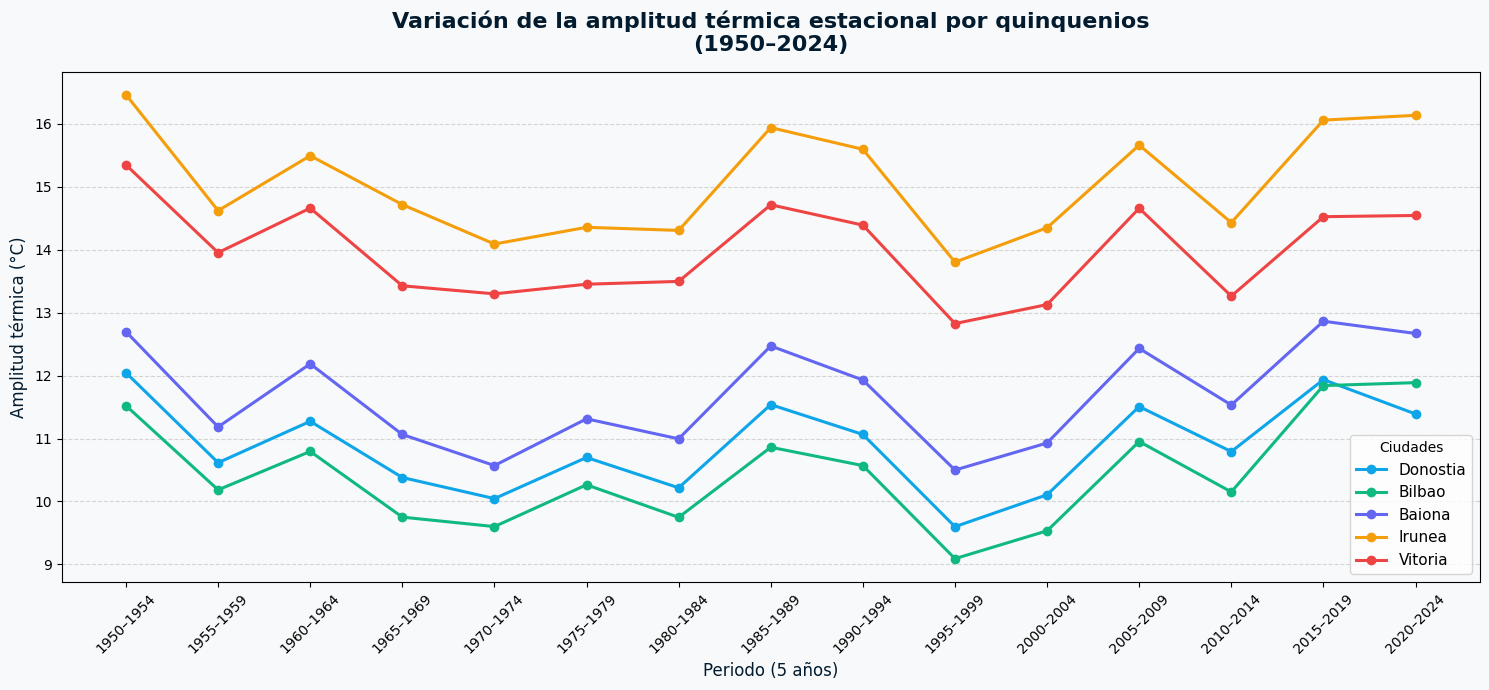

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from variables import csv_list

dfs = {}

# Cargar datos
for csv in csv_list:
    nombre = csv.split('_')[1].replace('.csv', '')
    dfs[nombre] = pd.read_csv(csv)

# Crear periodos de 5 años
def generar_quinquenios(inicio=1950, fin=2024):
    periodos = {}
    for año in range(inicio, fin + 1, 5):
        p_ini = año
        p_fin = min(año + 4, fin)
        etiqueta = f"{p_ini}–{p_fin}"
        periodos[etiqueta] = (p_ini, p_fin)
    return periodos

periodos = generar_quinquenios()

# Colores para los quinquenios (gradiente)
def generar_colores(n):
    cmap = plt.cm.get_cmap("turbo", n)
    return [cmap(i) for i in range(n)]

colores = generar_colores(len(periodos))

for ciudad, df in dfs.items():

    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor('#F8F9FA')
    ax.set_facecolor('#F8F9FA')

    for (periodo, (ini, fin)), color in zip(periodos.items(), colores):
        df_periodo = df[(df["año"] >= ini) & (df["año"] <= fin)]

        if df_periodo.empty:
            continue

        # Media mensual del periodo
        mensual = df_periodo.groupby("mes")["temperature_2m_mean"].mean()

        ax.plot(
            mensual.index,
            mensual.values,
            label=periodo,
            linewidth=1.8,
            color=color,
            alpha=0.8
        )

    # Estilo
    ax.set_title(
        f'Estacionalidad de la temperatura media mensual\n{ciudad.capitalize()} (quinquenios 1950–2024)',
        fontsize=15,
        fontweight='bold',
        color='#021B2E',
        pad=15
    )

    ax.set_xlabel('Mes', fontsize=12, color='#021B2E')
    ax.set_ylabel('Temperatura media (°C)', fontsize=12, color='#021B2E')
    ax.set_xticks(range(1, 13))
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(title="Periodos (5 años)", fontsize=9, ncol=3)

    plt.tight_layout()
    plt.savefig(f'estacionalidad_quinquenios_{ciudad}.png', dpi=180, bbox_inches='tight')
    plt.show()

# Crear periodos de 5 años
def generar_quinquenios(inicio=1950, fin=2024):
    periodos = {}
    for año in range(inicio, fin + 1, 5):
        p_ini = año
        p_fin = min(año + 4, fin)
        etiqueta = f"{p_ini}–{p_fin}"
        periodos[etiqueta] = (p_ini, p_fin)
    return periodos

periodos = generar_quinquenios()

# Diccionario para almacenar amplitudes por ciudad
amplitudes = {ciudad: [] for ciudad in dfs.keys()}
etiquetas_periodos = list(periodos.keys())

for ciudad, df in dfs.items():

    for periodo, (ini, fin) in periodos.items():
        df_periodo = df[(df["año"] >= ini) & (df["año"] <= fin)]

        if df_periodo.empty:
            amplitudes[ciudad].append(np.nan)
            continue

        mensual = df_periodo.groupby("mes")["temperature_2m_mean"].mean()

        if 1 in mensual.index and 7 in mensual.index:
            amp = mensual.loc[7] - mensual.loc[1]   # Julio - Enero
        else:
            amp = np.nan

        amplitudes[ciudad].append(amp)

# ───────────────────────────────────────────────
# GRÁFICO COMPARATIVO ENTRE CIUDADES
# ───────────────────────────────────────────────

plt.figure(figsize=(15, 7))
plt.gca().set_facecolor('#F8F9FA')
plt.gcf().patch.set_facecolor('#F8F9FA')

colores = {
    'donostia': '#0EA5E9',
    'bilbao':   '#10B981',
    'baiona':   '#6366F1',
    'irunea':   '#F59E0B',
    'vitoria':  '#EF4444'
}

for ciudad, valores in amplitudes.items():
    plt.plot(
        etiquetas_periodos,
        valores,
        label=ciudad.capitalize(),
        linewidth=2.2,
        color=colores[ciudad],
        marker='o'
    )

plt.title(
    'Variación de la amplitud térmica estacional por quinquenios\n(1950–2024)',
    fontsize=16,
    fontweight='bold',
    color='#021B2E',
    pad=15
)

plt.xlabel('Periodo (5 años)', fontsize=12, color='#021B2E')
plt.ylabel('Amplitud térmica (°C)', fontsize=12, color='#021B2E')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Ciudades', fontsize=11)
plt.tight_layout()

plt.savefig('comparativa_estacionalidad_ciudades.png', dpi=180, bbox_inches='tight')
plt.show()

